In [ ]:
# read a netcdf file

import numpy as np
import netCDF4 as nc

file_path = '/home/vcohen/cope/results/tier2/predictions_psl_ridge_tier2.nc'

with nc.Dataset(file_path, 'r') as nc_file:
    # print(nc_file.variables.keys())
    longitudes = np.array(nc_file.variables['longitude'])
    latitudes = np.array(nc_file.variables['latitude'])
    data = np.array(nc_file.variables['__xarray_dataarray_variable__'])


# flattent the grid
data = data.reshape(data.shape[0], data.shape[1], -1)

dict_keys(['model', 'time', 'longitude', 'latitude', '__xarray_dataarray_variable__'])


/tmp/ipykernel_26072/144648952.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  longitudes = np.array(nc_file.variables['longitude'])
/tmp/ipykernel_26072/144648952.py:12: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  latitudes = np.array(nc_file.variables['latitude'])
/tmp/ipykernel_26072/144648952.py:13: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword argument

(21, 1488, 72, 144)


Pred yearly shape (before mean): (21, 124, 12, 10368)
Using vmin=-1.8598687648773193, vmax=1.8598687648773193 for colorbar
Using vmin=-2.028243064880371, vmax=2.028243064880371 for colorbar
Using vmin=-1.7356925010681152, vmax=1.7356925010681152 for colorbar
Using vmin=-1.254905343055725, vmax=1.254905343055725 for colorbar
Using vmin=-2.0089657306671143, vmax=2.0089657306671143 for colorbar
Using vmin=-1.9541430473327637, vmax=1.9541430473327637 for colorbar
Using vmin=-1.3047068119049072, vmax=1.3047068119049072 for colorbar
Using vmin=-1.531245470046997, vmax=1.531245470046997 for colorbar
Using vmin=-2.8477859497070312, vmax=2.8477859497070312 for colorbar
Using vmin=-1.114809513092041, vmax=1.114809513092041 for colorbar
Using vmin=-1.2951810359954834, vmax=1.2951810359954834 for colorbar
Using vmin=-9.29358196258545, vmax=9.29358196258545 for colorbar
Using vmin=-1.8718465566635132, vmax=1.8718465566635132 for colorbar
Using vmin=-0.9432698488235474, vmax=0.9432698488235474 for c

/home/vcohen/cope/ForceSMIP/visualization.py:119: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(15, 8))


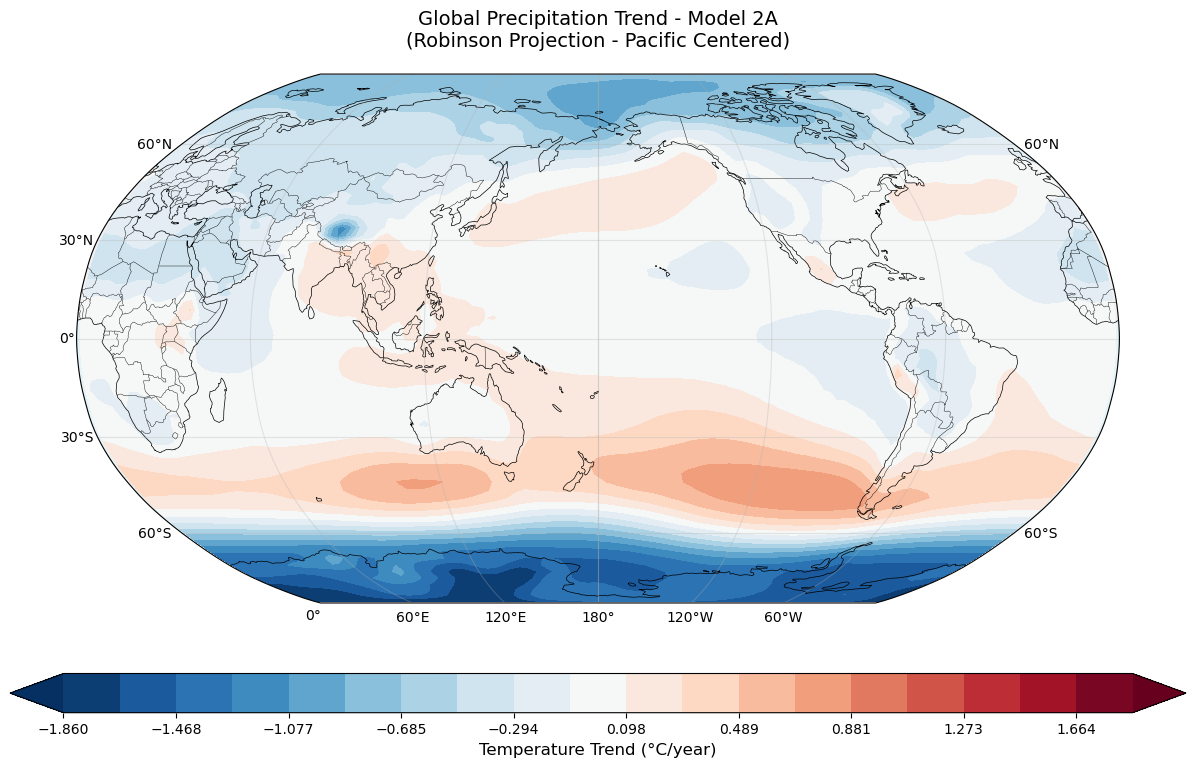

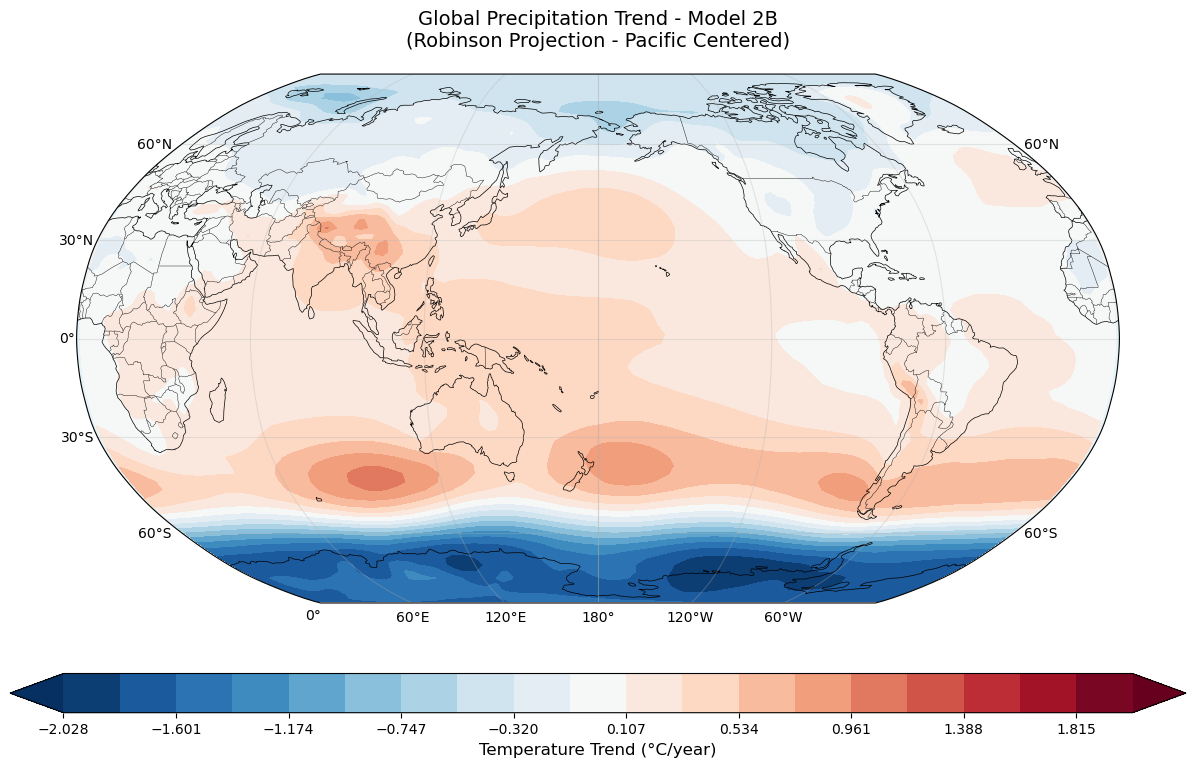

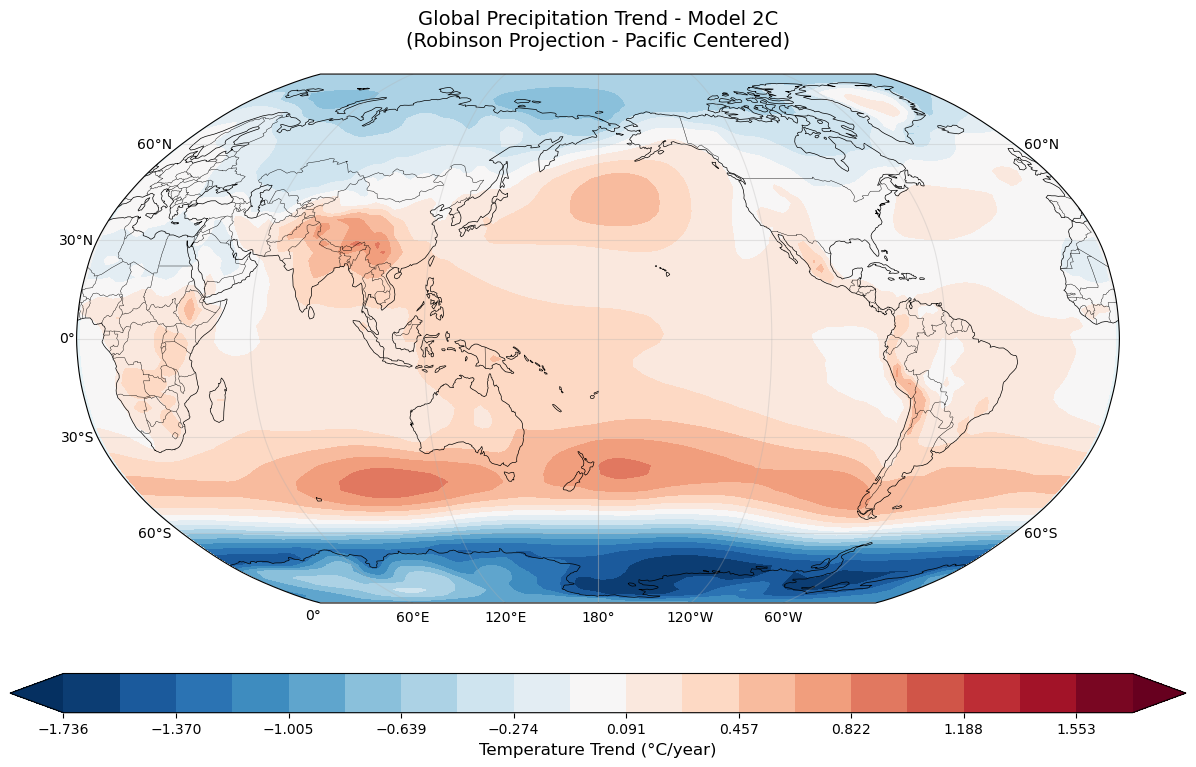

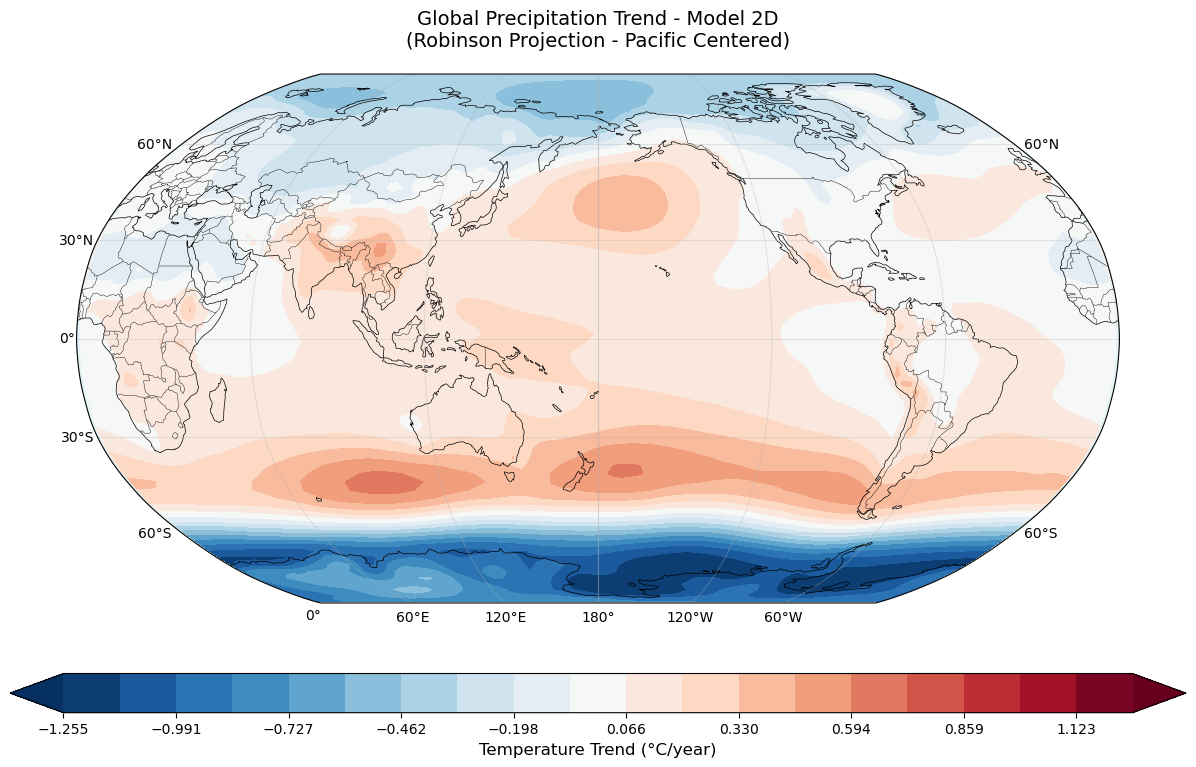

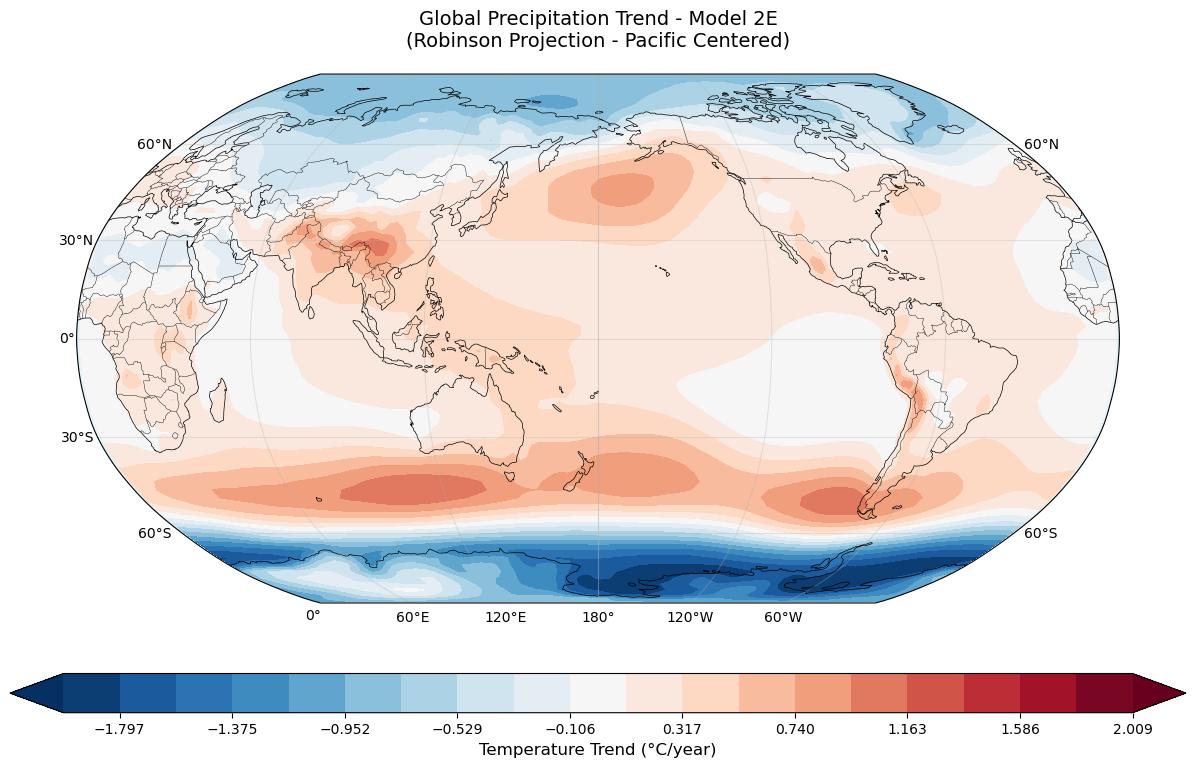

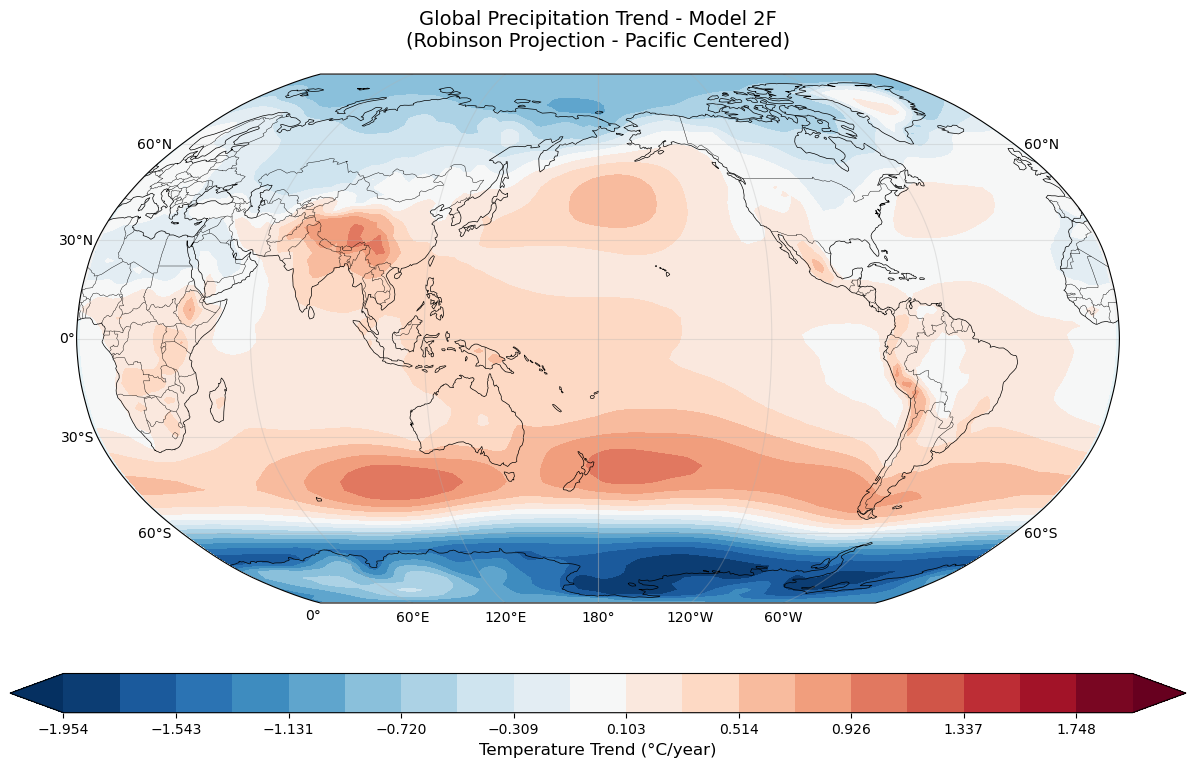

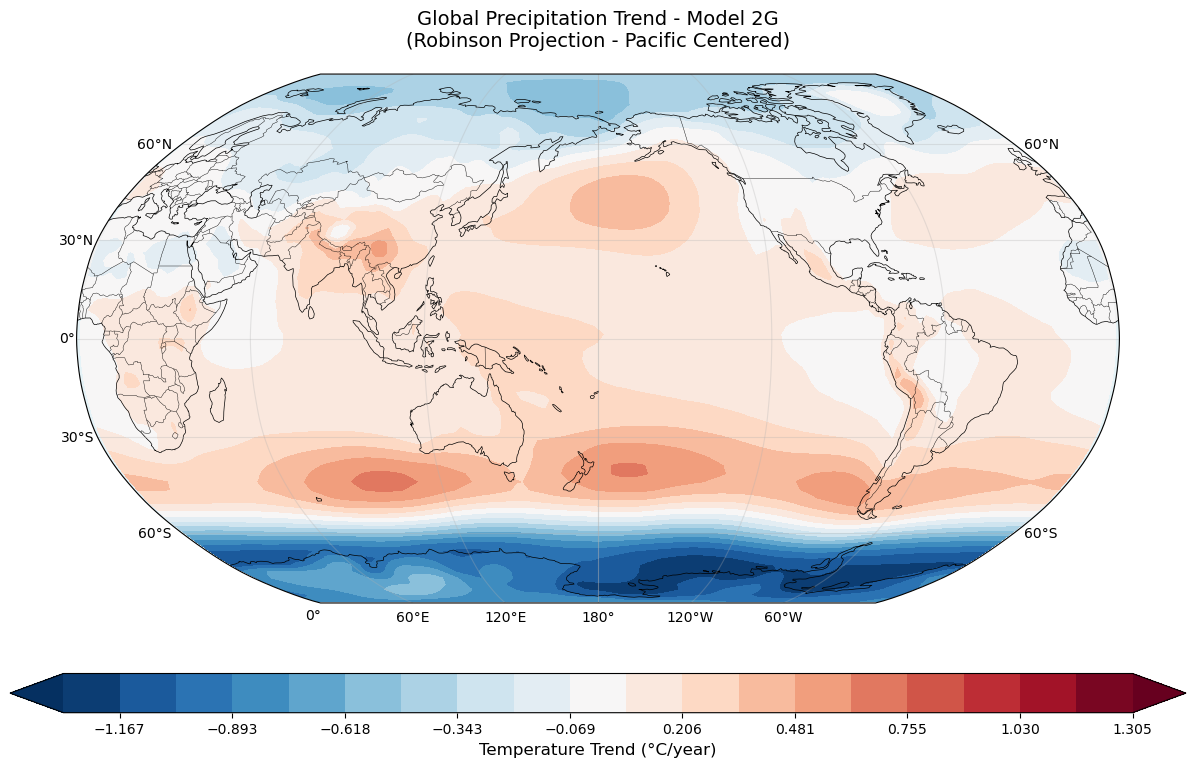

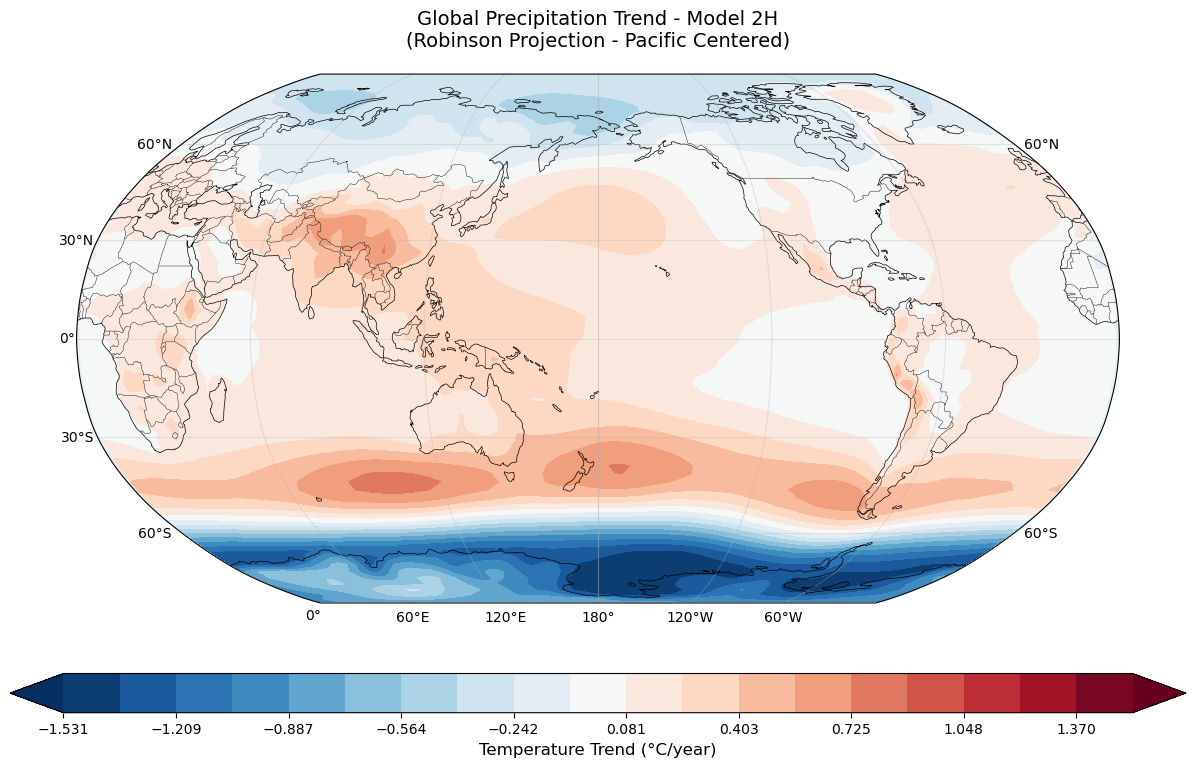

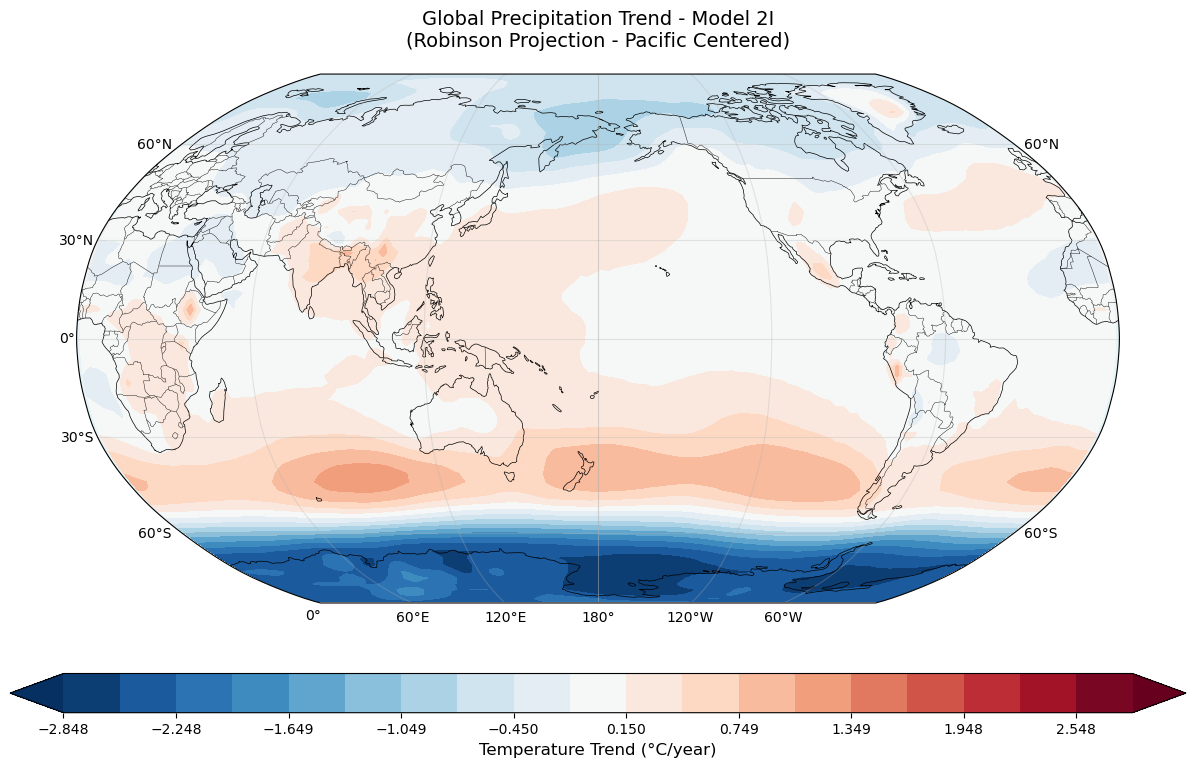

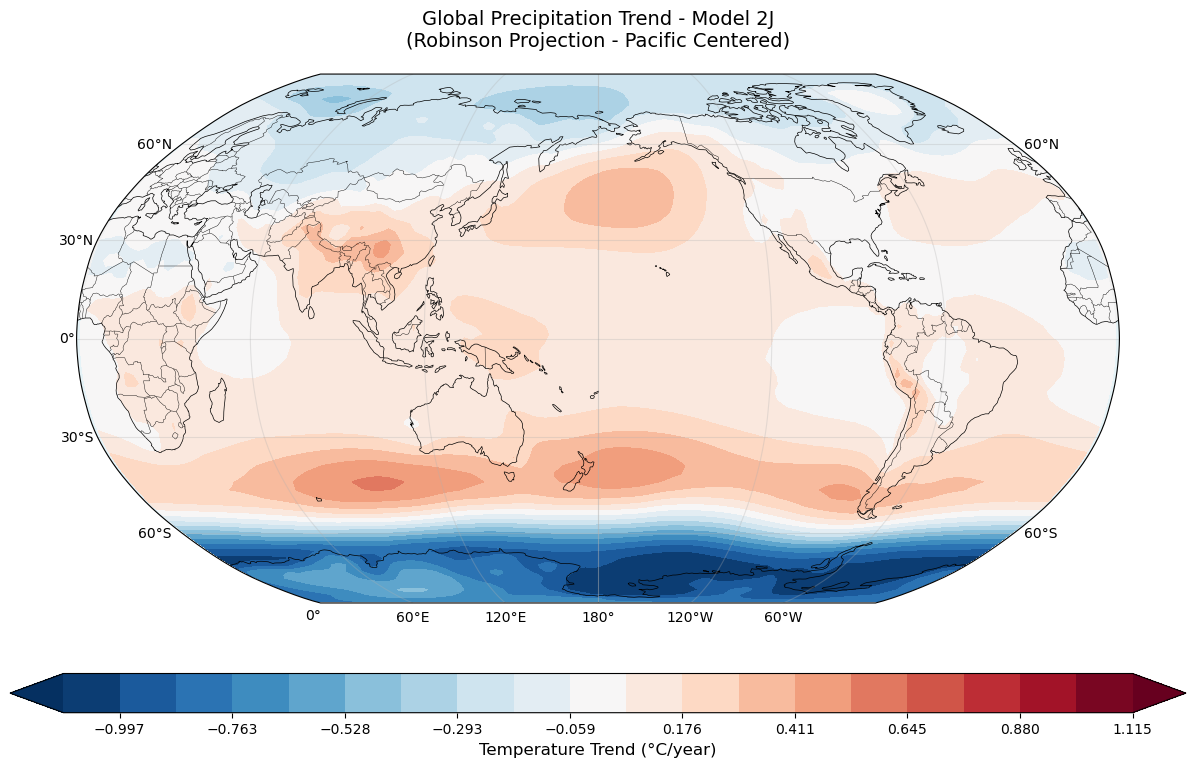

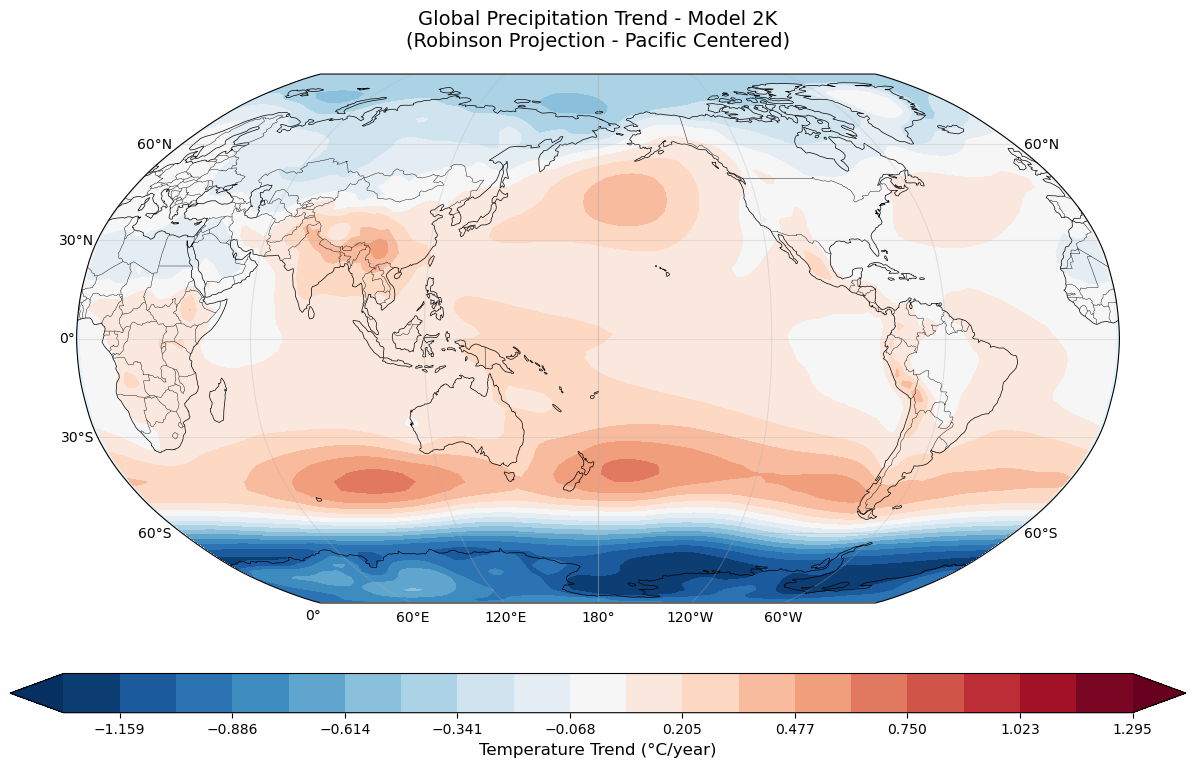

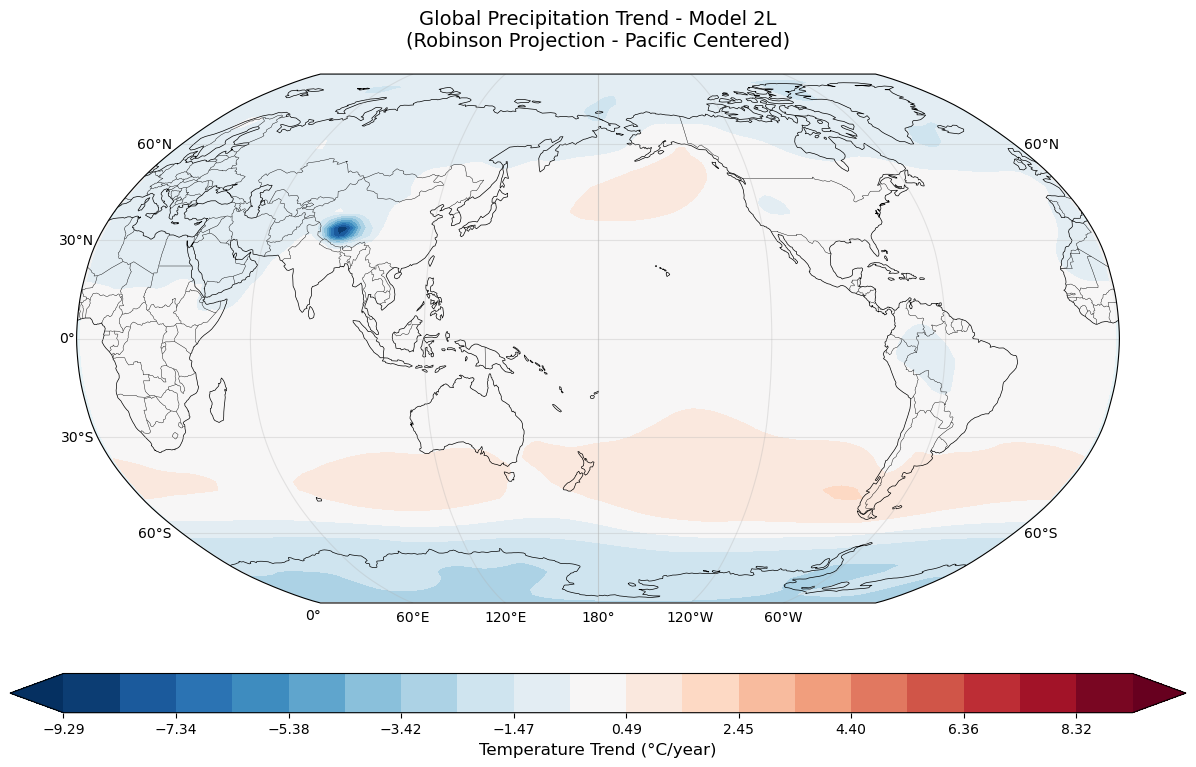

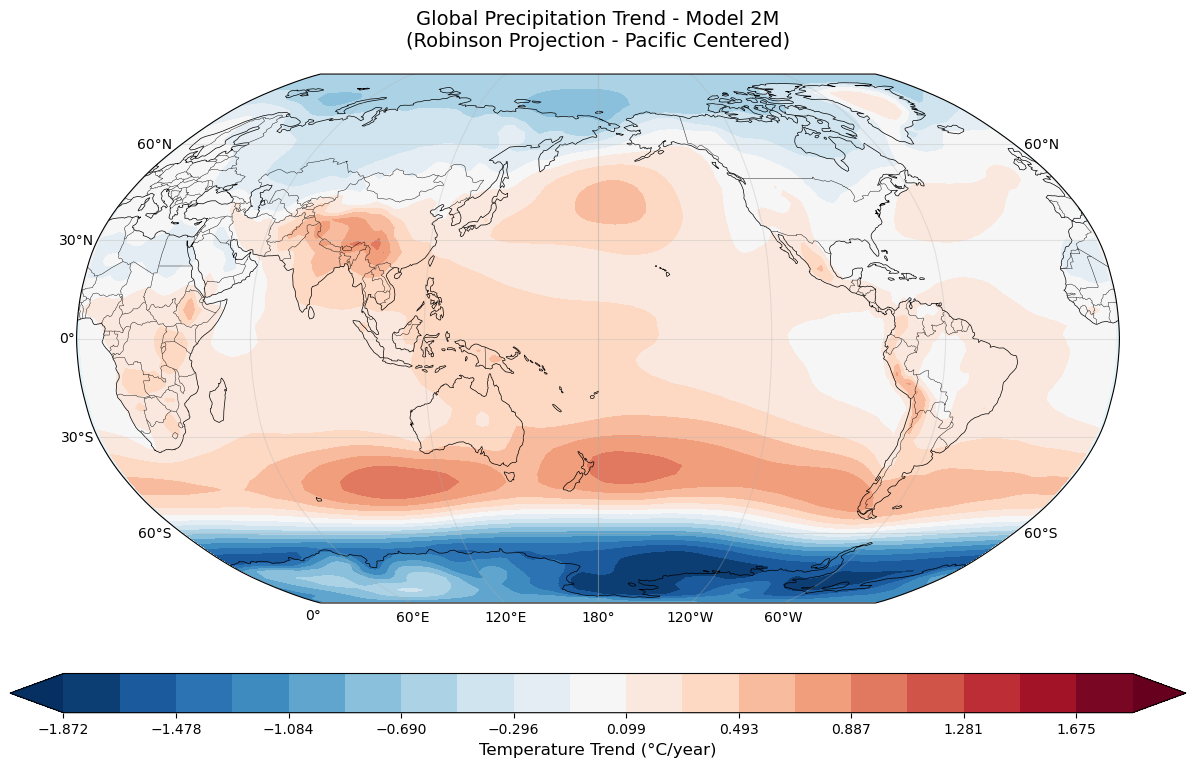

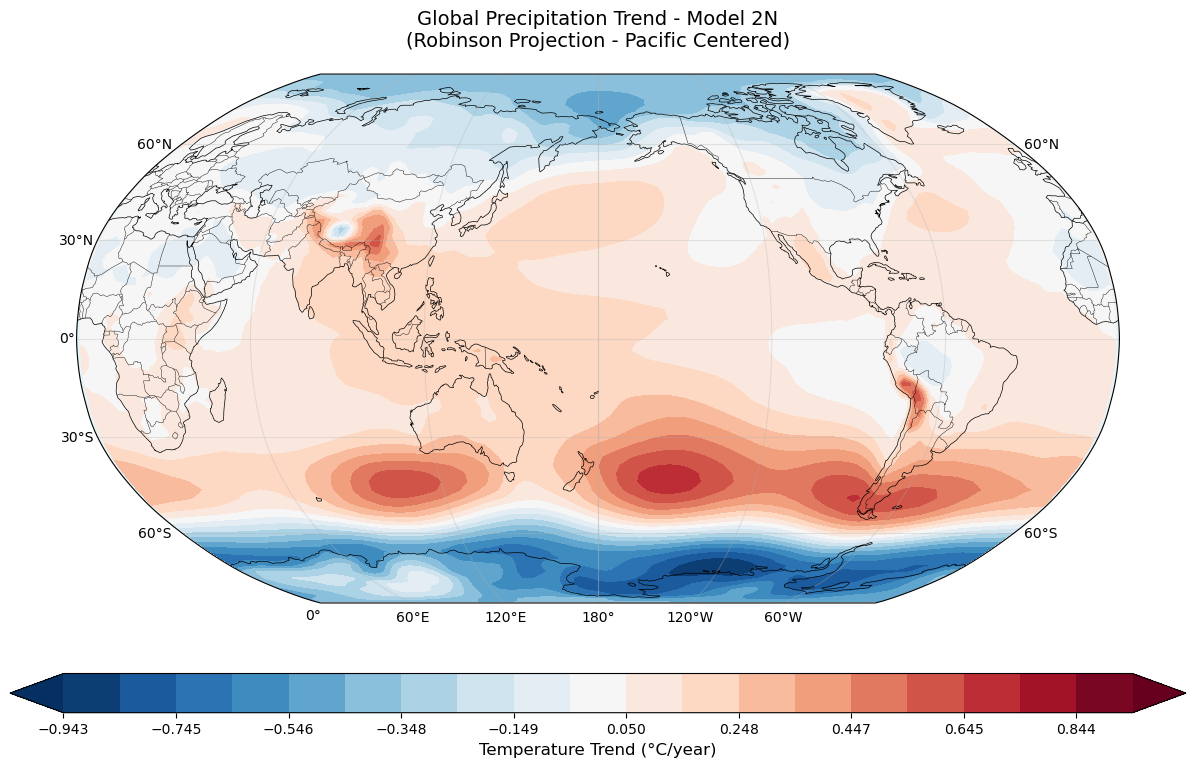

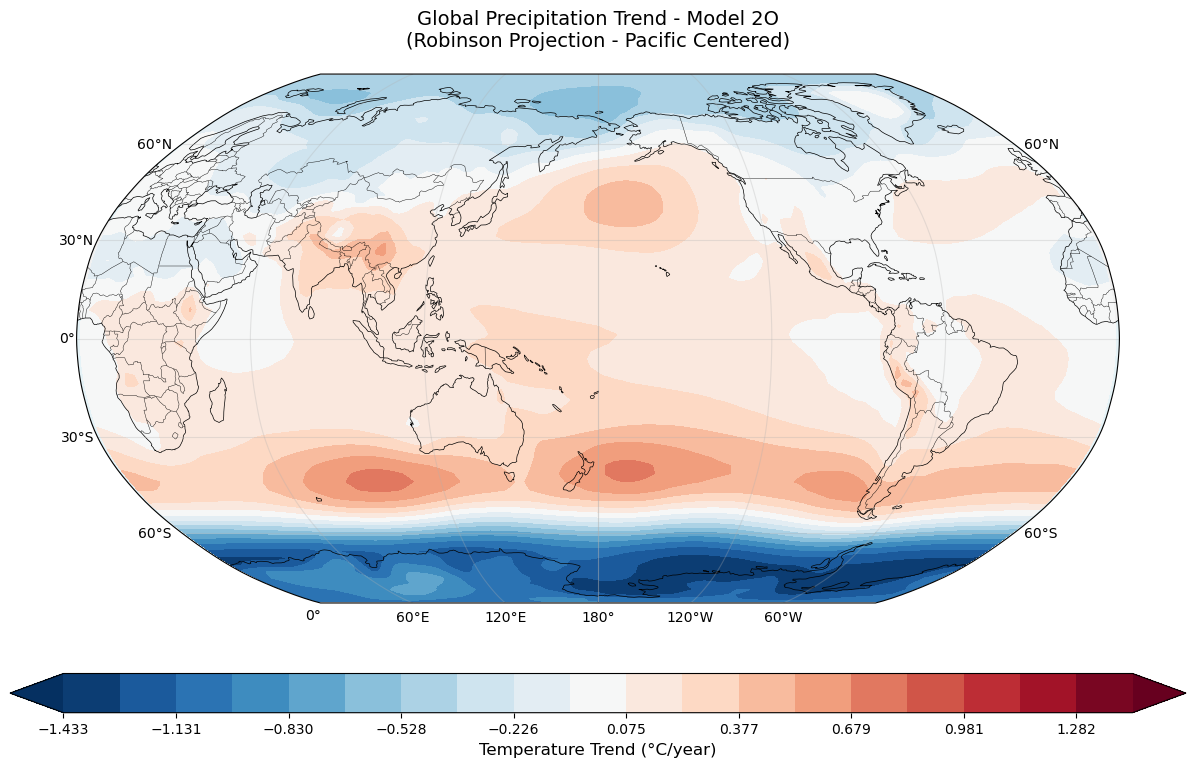

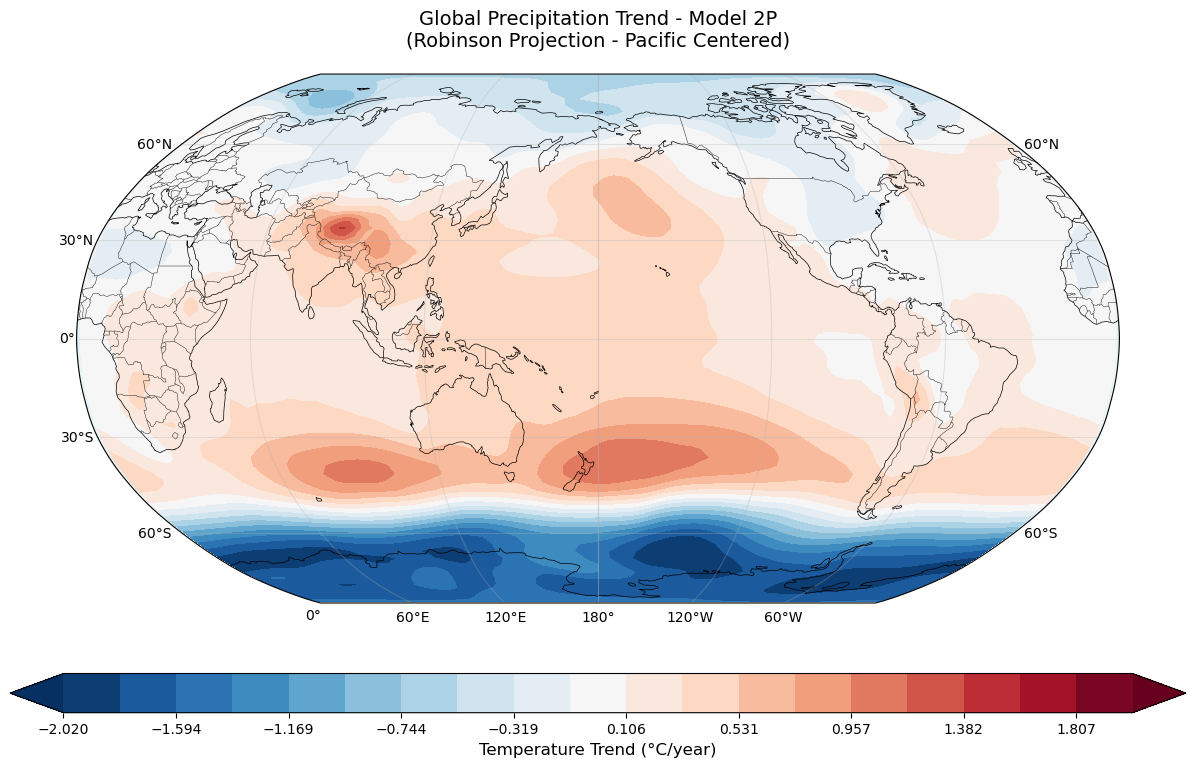

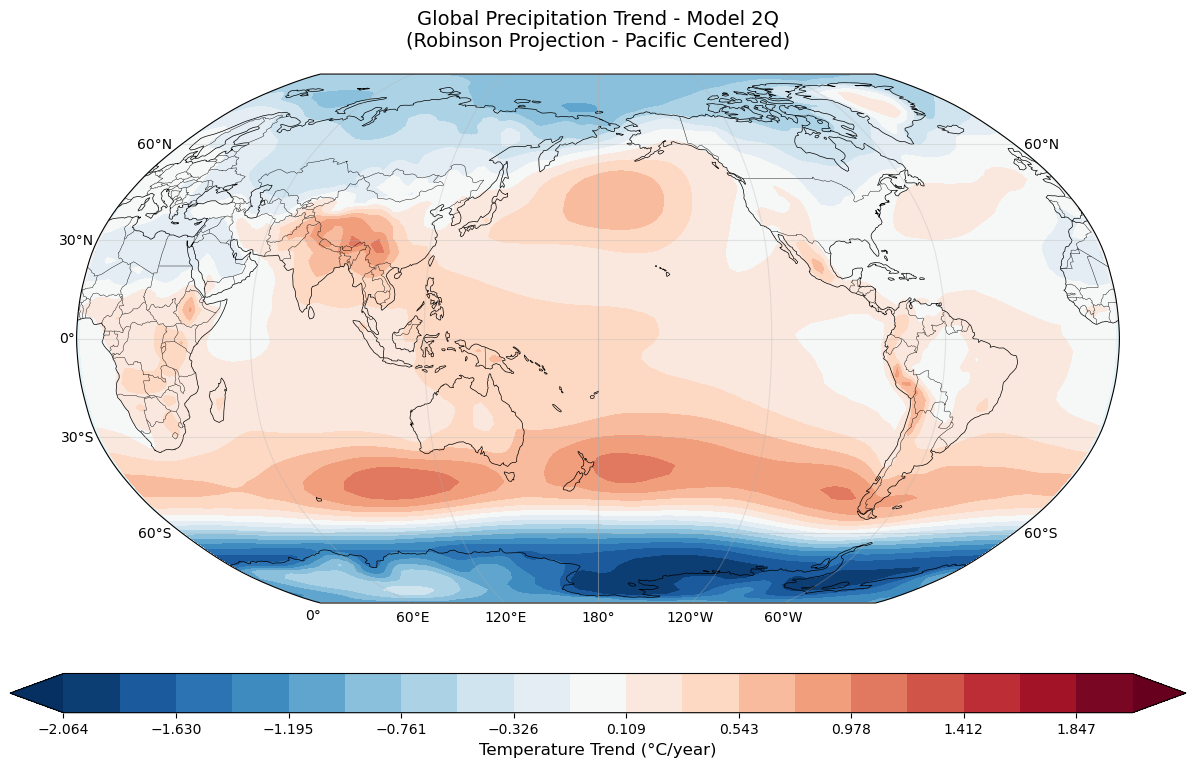

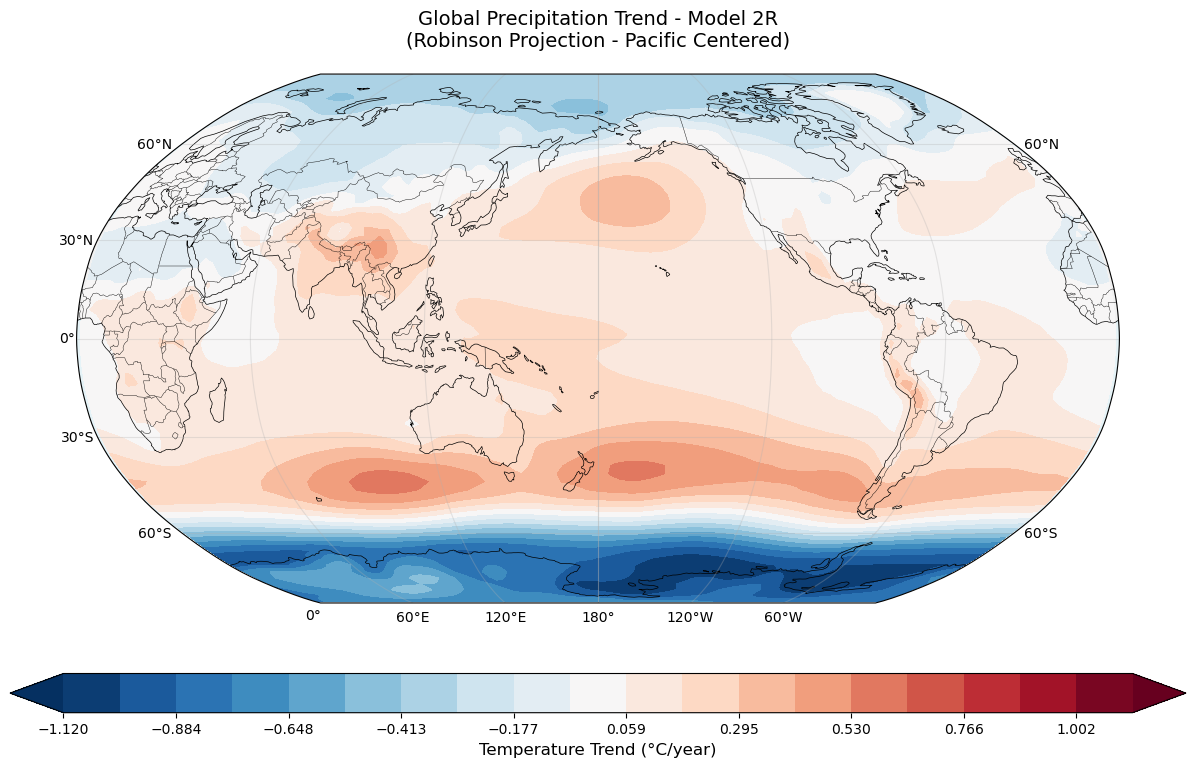

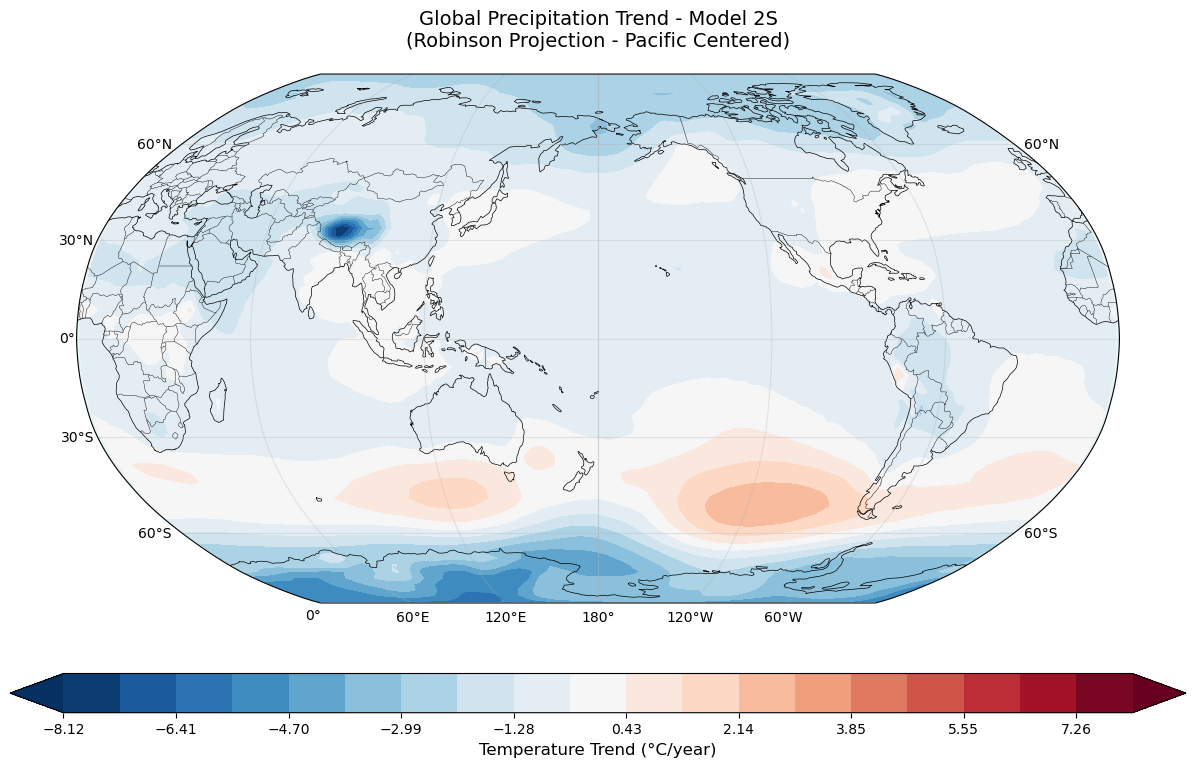

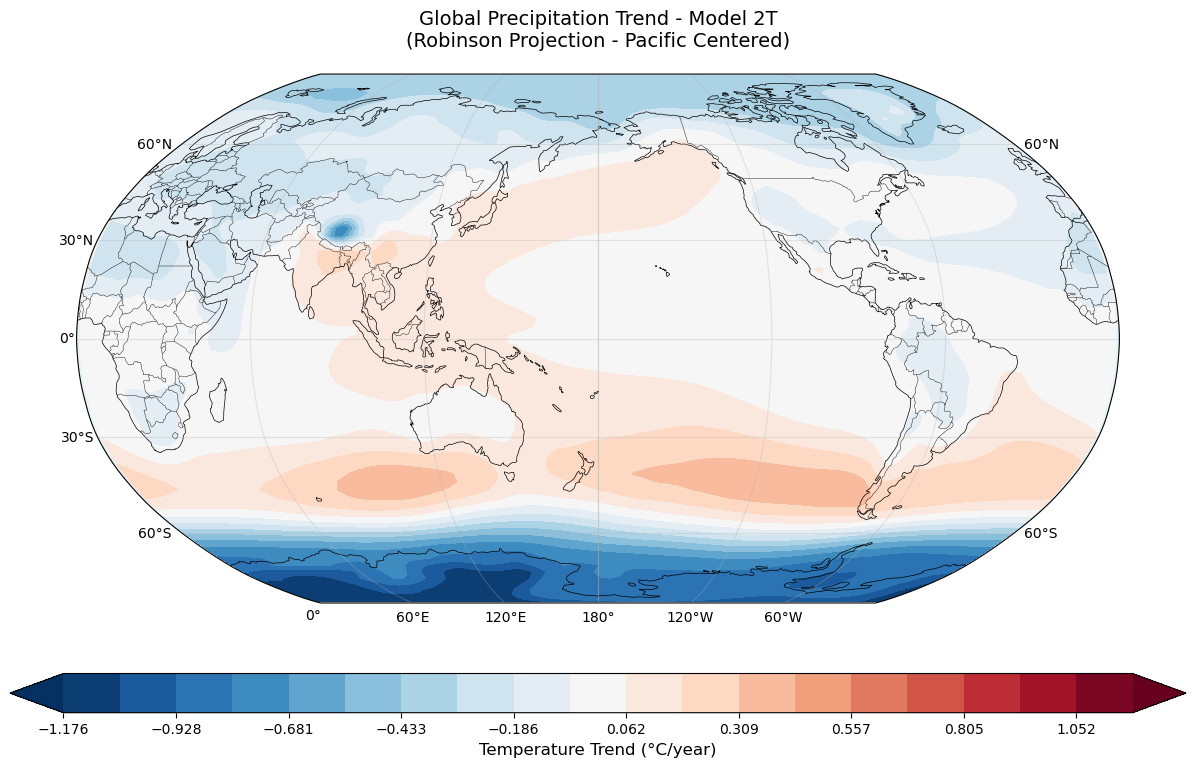

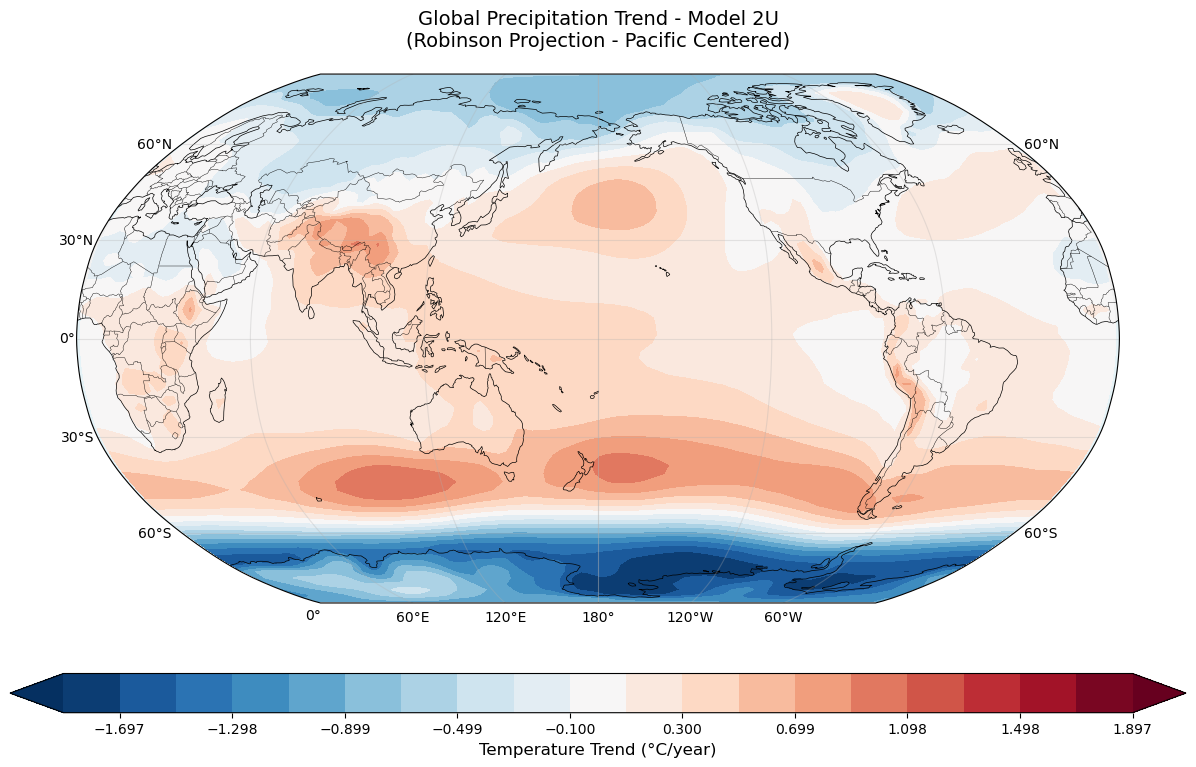

In [17]:
import torch
import os
import sys


# Add src to path
sys.path.append(os.path.join(os.getcwd(), "ForceSMIP"))
from evaluation import compute_trends_from_data
from visualization import ForceSMIPVisualizer

test_models = ['2A', '2B', '2C', '2D', '2E', '2F', '2G', '2H', '2I', '2J', '2K', '2L', '2M', '2N', '2O', '2P', '2Q', '2R', '2S', '2T', '2U']
# Initialize visualizer
visualizer = ForceSMIPVisualizer(longitudes, latitudes, test_models)

# Convert predictions to yearly averages and compute trends
def to_yearly_and_trends(pred_data, trend_years=slice(30, None)):
    """Helper function to convert monthly to yearly and compute trends."""
    pred_numpy = pred_data.cpu().numpy() if isinstance(pred_data, torch.Tensor) else pred_data
    pred_yearly = np.reshape(pred_numpy, (pred_numpy.shape[0], pred_numpy.shape[1] // 12, 12, pred_numpy.shape[2]))
    print(f"Pred yearly shape (before mean): {pred_yearly.shape}")
    pred_yearly = np.nanmean(pred_yearly, axis=2)
    return compute_trends_from_data(pred_yearly, trend_years)

# Compute trends for all predictions
trend_years = slice(0, None)  # Last 43 years for trend computation


# trends_ground_truth = compute_trends_from_data(data_ground_truth_yearly, trend_years)
trends_ridge = to_yearly_and_trends(data, trend_years)


for idx_run in range(trends_ridge.shape[0]):
    fig = visualizer.plot_robinson_projection(trends_ridge, 
                                    title="Global Precipitation Trend",
                                    cmap='RdBu_r',
                                    run_idx=idx_run,
                                    central_longitude=180)